# Customer 360 EDA — Part 3: Domain EDA & Preliminary Customer 360

**Part 3 of 3.** We now analyze each domain in depth (sales/orders, products/prices, CRM, complaints, product requests, quality, collections, offers) and assemble a **preliminary customer-level 360 view** to answer *"what do we actually know about each customer?"*.

> Requirements from [`docs/eda-requirements.md`](../docs/eda-requirements.md). **Observational only** — we describe associations, never causality.

**Covered:**
1. Sales / orders EDA
2. Product & price EDA
3. CRM EDA
4. Complaint EDA
5. Product-development requests EDA
6. Quality / lab EDA
7. Collections & offers (supporting signals)
8. Preliminary Customer 360 (customer-level aggregates)
9. Cross-source relationships
10. Key findings & recommendations


## 1. Setup & load

In [1]:
import os, re, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 200); pd.set_option("display.max_rows", 120)

def _find_repo_root():
    p = Path.cwd()
    for _ in range(8):
        if (p / "data" / "raw" / "DATASET.xlsx").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Could not locate repo root (data/raw/DATASET.xlsx) from " + str(Path.cwd()))

REPO = _find_repo_root()
RAW = REPO / "data" / "raw"


def load_workbook(path):
    xl = pd.ExcelFile(path)
    return {name: xl.parse(name) for name in xl.sheet_names}

DATA = load_workbook(REPO / "data" / "raw" / "DATASET.xlsx")
print("Sheets:", list(DATA.keys()))

# Convenience aliases
sales = DATA["فروش"].copy()
customers = DATA["مشتریان"].copy()
products = DATA["محصولات"].copy()
complaints = DATA["شکایات"].copy()
crm = DATA["تعاملات_CRM"].copy()
requests = DATA["درخواست_توسعه"].copy()
quality = DATA["کیفیت_لات"].copy()
collections = DATA["وصول"].copy()
offers = DATA["آفرها"].copy()


Sheets: ['مشتریان', 'محصولات', 'فاکتورها', 'فروش', 'اجزای_هزینه_تحقق', 'وصول', 'شکایات', 'اتصال_شکایت', 'تعاملات_CRM', 'درخواست_توسعه', 'کیفیت_لات', 'همبافت_لات', 'آفرها', 'سهم_سبد', 'سیگنال_بازار', 'برآورد_هزینه_ماهانه']


## 2. Sales / orders EDA

In [2]:
print("Sales lines:", len(sales), "rows")
print("Unique customers:", sales['Customer_ID'].nunique())
print("Unique products:", sales['Product_ID'].nunique())
print("Unique invoices:", sales['شماره فاکتور'].nunique())
print("Date range:", sales['تاریخ'].min(), "->", sales['تاریخ'].max())
print()
print("Numeric summary (مقدار=qty, قیمت فی فروش=unit price, مبلغ کل=total amount):")
sales[['مقدار', 'قیمت فی فروش', 'مبلغ کل']].describe().T


Sales lines: 52987 rows
Unique customers: 644
Unique products: 646
Unique invoices: 14423
Date range: 2019-12-16 -> 2026-07-22

Numeric summary (مقدار=qty, قیمت فی فروش=unit price, مبلغ کل=total amount):


,count,mean,std,min,25%,50%,75%,max
مقدار,52987.0,375.858184,908.762089,0.13,14.03,71.53,256.92,10070.00
قیمت فی فروش,52987.0,215.474569,203.678363,26.44,99.37,142.56,235.29,2085.97
مبلغ کل,52987.0,83467.348276,269249.241070,23.76,2052.02,10710.40,50505.79,4839975.10


In [3]:
# Revenue & order KPIs per customer
cust_orders = (sales.groupby('Customer_ID')
               .agg(Orders=('Sales_Line_ID','count'),
                    Revenue=('مبلغ کل','sum'),
                    Quantity=('مقدار','sum'),
                    Products=('Product_ID','nunique'),
                    LastDate=('تاریخ','max'))
               .reset_index())
cust_orders['AOV'] = cust_orders['Revenue'] / cust_orders['Orders']
cust_orders.head()


,Customer_ID,Orders,Revenue,Quantity,Products,LastDate,AOV
0,CUST-001,1,172720.0,1270.0,1,2026-02-07,1.727200e+05
1,CUST-002,1,471429.2,3490.0,1,2025-09-08,4.714292e+05
2,CUST-003,11,7203837.4,54110.0,6,2026-06-10,6.548943e+05
3,CUST-004,1,1337799.5,10070.0,1,2025-08-18,1.337800e+06
4,CUST-005,1,812964.6,6030.0,1,2025-09-14,8.129646e+05


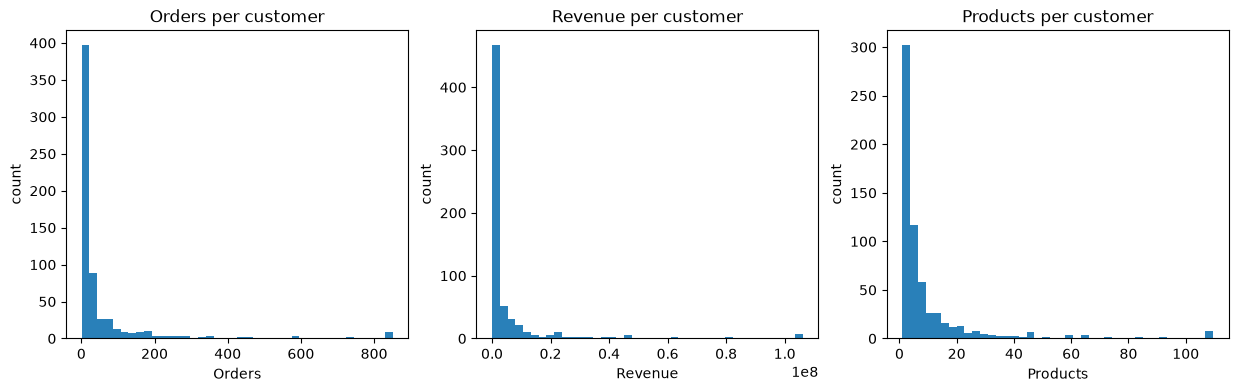

In [4]:
# Distributions of key sales metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['Orders','Revenue','Products'],
                          ['Orders per customer','Revenue per customer','Products per customer']):
    s = cust_orders[col].clip(upper=cust_orders[col].quantile(0.99))
    ax.hist(s, bins=40, color='#2980b9')
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('count')

plt.show()


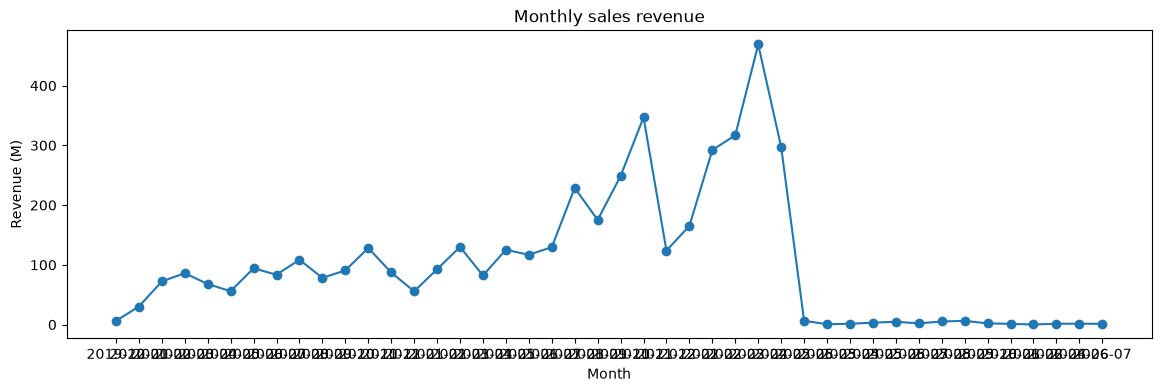

In [5]:
# Time trend of revenue (parse date)
s2 = sales.copy()
s2['date'] = pd.to_datetime(s2['تاریخ'], errors='coerce')
monthly = s2.dropna(subset=['date']).groupby(s2['date'].dt.to_period('M')).agg(
    Revenue=('مبلغ کل','sum'), Orders=('Sales_Line_ID','count')).reset_index()
monthly['month'] = monthly['date'].astype(str)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['month'], monthly['Revenue']/1e6, marker='o', label='Revenue (M)')
ax.set_title('Monthly sales revenue'); ax.set_xlabel('Month'); ax.set_ylabel('Revenue (M)')

plt.show()


In [6]:
# Payment type distribution
sales['نوع پرداخت'].value_counts()


نوع پرداخت
cash_or_prepaid        33700
short_term             10935
long_term               7998
payment_generalized      354
Name: count, dtype: int64

## 3. Product & price EDA

In [7]:
print("Products in master:", len(products))
print("Products sold (sales):", sales['Product_ID'].nunique())
print()
print("Product family distribution (sales):")
sales['گروه کالا'].value_counts()


Products in master: 646
Products sold (sales): 646

Product family distribution (sales):


گروه کالا
Product_Family_03             21752
Product_Family_04             13144
Product_Family_05              8240
Product_Family_02              6376
Product_Family_01              3161
Product_Family_06               241
Product_Family_GENERALIZED       73
Name: count, dtype: int64

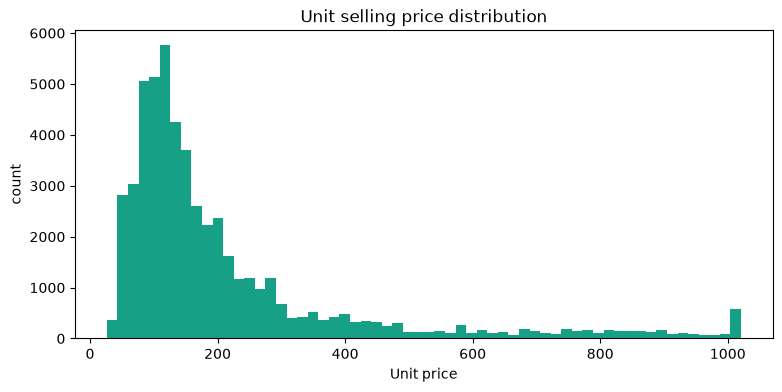

In [8]:
# Unit price distribution (sales)
fig, ax = plt.subplots(figsize=(9,4))
sp = sales['قیمت فی فروش'].clip(lower=0, upper=sales['قیمت فی فروش'].quantile(0.99))
ax.hist(sp, bins=60, color='#16a085')
ax.set_title('Unit selling price distribution'); ax.set_xlabel('Unit price'); ax.set_ylabel('count')

plt.show()


In [9]:
# Offer price vs base price relationship (discount behavior)
offers2 = offers.dropna(subset=['Base_Price_per_unit','Offered_Price_per_unit'])
offers2['discount'] = offers2['Offer_Discount_Pct']
print("Offers:", len(offers2))
print("Offer types:", offers['Offer_Type'].value_counts().to_dict())
print("Result:", offers['Result'].value_counts().to_dict())


Offers: 2500
Offer types: {'مدت\u200cدار': 918, 'قیمتی': 798, 'حجمی': 784}
Result: {'رد': 662, 'قبول': 651, 'منقضی\u200cشده': 642, 'درحال مذاکره': 545}


## 4. CRM EDA

In [10]:
# Use latest Record_Version per Interaction_ID (per integration guide)
latest = crm.sort_values(['Interaction_ID','Record_Version']).groupby('Interaction_ID').tail(1)
print("CRM interactions (latest version):", len(latest))
print("Unique customers:", latest['Customer_ID'].nunique())
print()
print()
print("Interaction type:", latest['Interaction_Type'].value_counts().to_dict())
print()
print("Next action:", latest['Next_Action'].value_counts().to_dict())
print()
print("Date range:", latest['Event_Time'].min(), "->", latest['Event_Time'].max())


CRM interactions (latest version): 3865
Unique customers: 624


Interaction type: {'پیگیری سفارش': 780, 'قیمت و تخفیف': 678, 'برنامه خرید': 566, 'وصول مطالبات': 523, 'کیفیت محصول': 513, 'خدمات فنی': 403, 'نمونه محصول': 402}

Next action: {'پیگیری تلفنی': 1151, 'بدون اقدام': 740, 'بازدید فنی': 719, 'جلسه قیمت': 675, 'ارسال نمونه': 580}

Date range: 2019-12-26 -> 2022-08-10


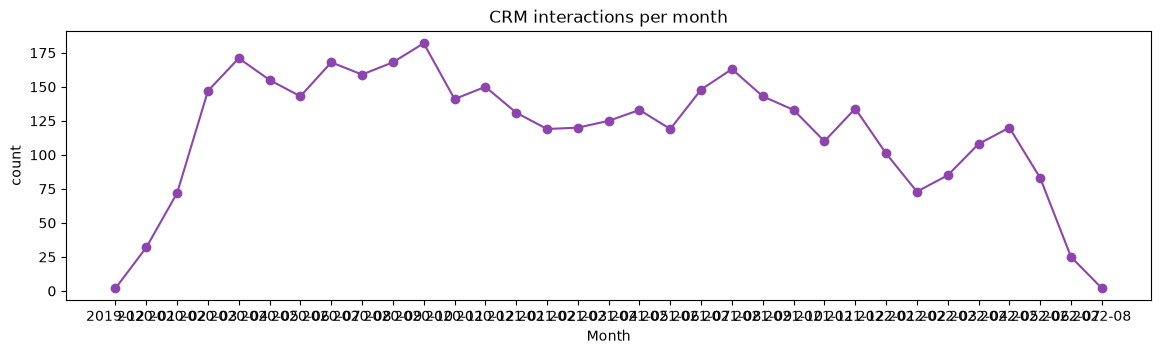

In [11]:
# CRM interaction frequency over time
c2 = latest.copy(); c2['date'] = pd.to_datetime(c2['Event_Time'], errors='coerce')
crm_monthly = c2.dropna(subset=['date']).groupby(c2['date'].dt.to_period('M')).size()
crm_monthly = crm_monthly.reset_index(); crm_monthly.columns=['month','count']
crm_monthly['month']=crm_monthly['month'].astype(str)
fig, ax = plt.subplots(figsize=(14,3.5))
ax.plot(crm_monthly['month'], crm_monthly['count'], color='#8e44ad', marker='o')
ax.set_title('CRM interactions per month'); ax.set_xlabel('Month'); ax.set_ylabel('count')

plt.show()


In [12]:
# CRM text length distribution (semantic potential)
lens = latest['Summary_Text'].dropna().astype(str).str.len()
print("Summary_Text length: mean", round(lens.mean()), "median", int(lens.median()))


Summary_Text length: mean 103 median 101


## 5. Complaint EDA

In [13]:
print("Complaints:", len(complaints))
print("Unique customers:", complaints['Customer_ID'].nunique())
print("Unique products:", complaints['Product_ID'].nunique())
print()
print("Severity:", complaints['Severity'].value_counts().to_dict())
print()
print("Status:", complaints['Complaint_Status'].value_counts().to_dict())
print()
print()
print("Date range:", complaints['Created_At'].min(), "->", complaints['Created_At'].max())


Complaints: 520
Unique customers: 169
Unique products: 187

Severity: {'متوسط': 226, 'زیاد': 131, 'کم': 129, 'بحرانی': 34}

Status: {'بسته\u200cشده': 334, 'درحال بررسی': 146, 'پذیرفته\u200cشده': 28, 'ردشده': 8, 'نیازمند بررسی': 4}


Date range: 2020-01-22 -> 2026-08-06


In [14]:
# Top complaint titles
complaints['Complaint_Title'].value_counts().head(12)


Complaint_Title
فیلامنت و پرز              45
شید رنگ                    36
بدپیچی / سفتی بسته         28
مینگل بیشتر از حد          21
الصاق لیبل اشتباه          18
استحکام پایین / پارگی      18
مینگل کمتر از حد           18
روغن نامتوازن              18
دوک دست دوم / خرابی دوک    15
خرابی دوک و بسته‌بندی      15
کریمپ / حجم ناهمگون        15
بازشدن لا / جدایش          14
Name: count, dtype: int64

In [15]:
# Complaints per customer
cpc = complaints.groupby('Customer_ID').size().sort_values(ascending=False)
print("Complaints per customer (top 10):")
print(cpc.head(10).to_string())
print()
print("Mean complaints per customer:", round(cpc.mean(),2))


Complaints per customer (top 10):
Customer_ID
C_683666    37
C_746892    35
C_317124    21
C_117580    21
C_806376    17
C_113139    14
C_245948    14
C_126481    10
C_172705     9
C_479796     8

Mean complaints per customer: 3.08


## 6. Product-development requests EDA

In [16]:
print("Requests:", len(requests))
print("Unique customers:", requests['Customer_ID'].nunique())
print()
print("Request type:", requests['Request_Type'].value_counts().to_dict())
print()
print()
print("Status:", requests['Status'].value_counts().to_dict())
print()
print("Date range:", requests['Created_At'].min(), "->", requests['Created_At'].max())


Requests: 800
Unique customers: 204

Request type: {'تغییر تعداد فیلامنت': 150, 'بسته\u200cبندی اختصاصی': 144, 'کاهش پرز': 143, 'بهبود استحکام': 137, 'تغییر دنیر': 133, 'بهبود شید رنگ': 93}


Status: {'درحال بررسی': 247, 'درحال توسعه': 187, 'نمونه تأیید': 184, 'فنی رد': 182}

Date range: 2020-02-04 -> 2022-09-16


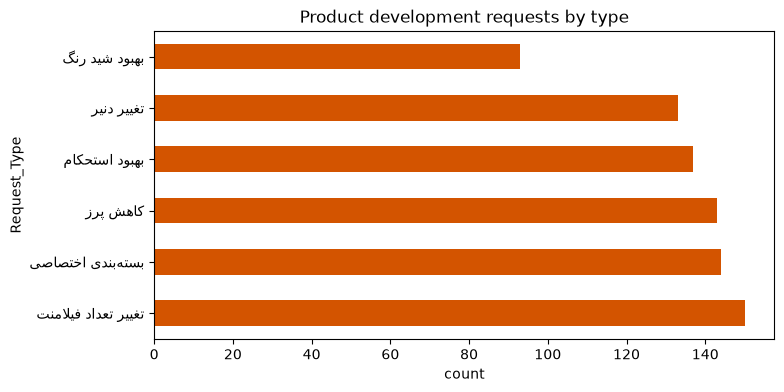

In [17]:
# Most requested types — customer needs signal
req_types = requests['Request_Type'].value_counts()
req_types.plot(kind='barh', color='#d35400', figsize=(8,4))
plt.title('Product development requests by type'); plt.xlabel('count')

plt.show()


## 7. Quality / lab EDA

In [18]:
print("Quality records:", len(quality))
print("Unique sales lines:", quality['Sales_Line_ID'].nunique())
print("Lab result:", quality['Lab_Result'].value_counts().to_dict())
print()
q = quality[['Tensile_Strength_cN_dtex','Elongation_Pct','Evenness_CV_Pct','Oil_Pickup_Pct']]
print(q.describe().T)


Quality records: 13865
Unique sales lines: 13865
Lab result: {'قبول': 13853, 'رد': 12}

                            count      mean       std     min     25%     50%     75%     max
Tensile_Strength_cN_dtex  13865.0  3.893784  0.635060  2.8000  3.3500  3.8900  4.4400  4.9900
Elongation_Pct            13865.0  0.263826  0.048930  0.1800  0.2220  0.2630  0.3060  0.3490
Evenness_CV_Pct           13865.0  0.015942  0.004608  0.0080  0.0119  0.0159  0.0199  0.0239
Oil_Pickup_Pct            13865.0  0.007923  0.002594  0.0035  0.0057  0.0079  0.0101  0.0124


## 8. Collections & offers (supporting signals)

In [19]:
print("Collections:", len(collections))
print("Unique customers:", collections['Customer_ID'].nunique())
print("Bounced checks:", collections['چک برگشتی'].value_counts().to_dict())
print()
print("Delay days (روز تأخیر) describe:")
print(collections['روز تأخیر'].describe())


Collections: 15652
Unique customers: 631
Bounced checks: {'خیر': 15559, 'بله': 93}

Delay days (روز تأخیر) describe:
count    15652.000000
mean        23.452977
std         15.798319
min          0.000000
25%          9.000000
50%         23.000000
75%         37.000000
max         56.000000
Name: روز تأخیر, dtype: float64


In [20]:
print("Offers:", len(offers))
print("Unique customers:", offers['Customer_ID'].nunique())
print("Result distribution:", offers['Result'].value_counts().to_dict())
print()
print("Offer reason:", offers['Offer_Reason'].value_counts().to_dict())


Offers: 2500
Unique customers: 323
Result distribution: {'رد': 662, 'قبول': 651, 'منقضی\u200cشده': 642, 'درحال مذاکره': 545}

Offer reason: {'تسویه سریع': 372, 'افزایش حجم سفارش': 371, 'معرفی محصول جدید': 365, 'افزایش سهم از سبد': 355, 'حفظ مشتری کلیدی': 352, 'رقابت قیمتی': 351, 'آزمون محصول': 334}


## 9. Preliminary Customer 360

We combine per-customer aggregates from every source into one **customer-level table**. This answers *"what do we actually know about each customer?"*.


In [21]:
# Rebuild the 360 table cleanly
c360 = customers[['Customer_ID','Customer_Segment','Customer_Status','Credit_Limit']].copy()
c360['n_orders'] = c360['Customer_ID'].map(sales.groupby('Customer_ID')['Sales_Line_ID'].count())
c360['revenue'] = c360['Customer_ID'].map(sales.groupby('Customer_ID')['مبلغ کل'].sum())
c360['n_products'] = c360['Customer_ID'].map(sales.groupby('Customer_ID')['Product_ID'].nunique())
c360['n_collections'] = c360['Customer_ID'].map(collections.groupby('Customer_ID')['Collection_ID'].count())
c360['collected'] = c360['Customer_ID'].map(collections.groupby('Customer_ID')['مبلغ وصول'].sum())
c360['n_complaints'] = c360['Customer_ID'].map(complaints.groupby('Customer_ID')['Complaint_ID'].count())
c360['n_crm'] = c360['Customer_ID'].map(latest.groupby('Customer_ID')['Interaction_ID'].count())
c360['n_requests'] = c360['Customer_ID'].map(requests.groupby('Customer_ID')['Request_ID'].count())
c360['n_offers'] = c360['Customer_ID'].map(offers.groupby('Customer_ID')['Offer_ID'].count())
c360['n_quality'] = c360['Customer_ID'].map(quality.groupby('Customer_ID')['Sales_Line_ID'].count()) if 'Customer_ID' in quality.columns else 0
c360 = c360.fillna(0)

print("Customer 360 rows:", len(c360))
c360.head()


Customer 360 rows: 644


,Customer_ID,Customer_Segment,Customer_Status,Credit_Limit,n_orders,revenue,n_products,n_collections,collected,n_complaints,n_crm,n_requests,n_offers,n_quality
0,C_009817,B,غیرفعال,35000,1,22915.95,1,2.0,22915.95,0.0,5.0,0.0,0.0,0
1,C_010119,C,غیرفعال,43000,5,75990.32,3,6.0,72591.32,0.0,5.0,0.0,0.0,0
2,C_010649,B,فعال,5630000,104,15602480.76,3,25.0,14793589.62,0.0,7.0,3.0,6.0,0
3,C_011055,A,فعال,84000,6,168414.09,4,3.0,112988.16,0.0,5.0,0.0,2.0,0
4,C_014775,A,غیرفعال,789000,3,607860.36,1,2.0,537204.51,0.0,5.0,0.0,0.0,0


In [22]:
# Customer value ranking + data richness
c360['value'] = c360['revenue']
print("Top 10 customers by revenue:")
c360.sort_values('value', ascending=False).head(10)


Top 10 customers by revenue:


,Customer_ID,Customer_Segment,Customer_Status,Credit_Limit,n_orders,revenue,n_products,n_collections,collected,n_complaints,n_crm,n_requests,n_offers,n_quality,value
585,C_937594,C,فعال,7312000,631,3.605522e+08,6,423.0,3.350672e+08,5.0,15.0,8.0,35.0,0,3.605522e+08
140,C_245948,A,فعال,8961000,1333,3.136261e+08,21,330.0,2.805349e+08,14.0,15.0,16.0,67.0,0,3.136261e+08
391,C_633661,A,فعال,5504000,821,2.153053e+08,8,342.0,1.887341e+08,7.0,15.0,11.0,32.0,0,2.153053e+08
335,C_535756,C,فعال,7508000,578,1.667987e+08,22,212.0,1.521163e+08,4.0,15.0,9.0,27.0,0,1.667987e+08
416,C_683666,A,فعال,6463000,3995,1.530468e+08,82,259.0,1.223483e+08,37.0,15.0,71.0,194.0,0,1.530468e+08
27,C_050237,C,فعال,7459000,310,1.307301e+08,7,133.0,1.184322e+08,1.0,15.0,10.0,14.0,0,1.307301e+08
29,C_051535,C,فعال,7122000,289,1.183393e+08,15,133.0,1.025605e+08,2.0,15.0,3.0,19.0,0,1.183393e+08
171,C_299317,B,فعال,11700000,147,9.012003e+07,12,65.0,8.134707e+07,1.0,9.0,3.0,11.0,0,9.012003e+07
501,C_806376,C,غیرفعال,1792000,2368,8.248045e+07,91,770.0,7.183810e+07,17.0,15.0,41.0,113.0,0,8.248045e+07
472,C_762928,B,فعال,6804000,257,8.167892e+07,10,112.0,6.894650e+07,3.0,13.0,7.0,16.0,0,8.167892e+07


In [23]:
# Data richness: how many of the main sources a customer appears in
main_sources = ['n_orders','n_complaints','n_crm','n_requests','n_offers','n_collections']
c360['sources_covered'] = (c360[main_sources] > 0).sum(axis=1)
print("Distribution of #sources per customer (out of %d):" % len(main_sources))
print(c360['sources_covered'].value_counts().sort_index().to_string())


Distribution of #sources per customer (out of 6):
sources_covered
2     10
3    273
4    157
5     96
6    108


In [24]:
# Segments vs behavior
print("Average revenue & activity by customer segment:")
c360.groupby('Customer_Segment')[['revenue','n_orders','n_complaints','n_crm']].mean()


Average revenue & activity by customer segment:


,revenue,n_orders,n_complaints,n_crm
Customer_Segment,,,,
A,6.980161e+06,93.030303,0.943723,5.974026
B,5.464730e+06,64.116505,0.655340,5.912621
C,8.137840e+06,88.352657,0.806763,6.120773


In [25]:
# Customers with only sales / only CRM / no linkage (sparse-data customers)
only_sales = ((c360['n_orders'] > 0) & (c360[['n_crm','n_complaints','n_requests','n_offers']] == 0).all(axis=1)).sum()
print("Customers with ONLY sales (no CRM/complaints/requests/offers):", int(only_sales))
print("Customers with NO sales at all:", int((c360['n_orders']==0).sum()))
print("Customers with NO activity in any source:", int((c360[main_sources]==0).all(axis=1).sum()))


Customers with ONLY sales (no CRM/complaints/requests/offers): 0
Customers with NO sales at all: 0
Customers with NO activity in any source: 0


## 10. Cross-source relationships

We quantify per-customer relationship between source volumes (orders ↔ complaints ↔ CRM) and highlight sources that carry information not available elsewhere.


In [26]:
# Correlation between key activity counts (observational)
act = c360[['n_orders','n_complaints','n_crm','n_requests','n_offers','revenue']].copy()
print("Correlation of activity counts (Pearson):")
act.corr().round(3)


Correlation of activity counts (Pearson):


,n_orders,n_complaints,n_crm,n_requests,n_offers,revenue
n_orders,1.000,0.953,0.594,0.978,0.993,0.497
n_complaints,0.953,1.000,0.518,0.929,0.950,0.467
n_crm,0.594,0.518,1.000,0.561,0.592,0.540
n_requests,0.978,0.929,0.561,1.000,0.971,0.462
n_offers,0.993,0.950,0.592,0.971,1.000,0.502
revenue,0.497,0.467,0.540,0.462,0.502,1.000


In [27]:
# Relationship counts summary (typical customer)
print("Per-customer averages across sources:")
print(c360[['n_orders','n_complaints','n_crm','n_requests','n_offers','n_collections']].mean().round(2).to_string())


Per-customer averages across sources:
n_orders         82.28
n_complaints      0.81
n_crm             6.00
n_requests        1.24
n_offers          3.88
n_collections    24.30


In [28]:
# Unique info per source (records that carry info not in sales)
print("Complaints customers not in sales:", len(set(complaints['Customer_ID']) - set(sales['Customer_ID'])))
print("Request customers not in sales:", len(set(requests['Customer_ID']) - set(sales['Customer_ID'])))
print("Offer customers not in sales:", len(set(offers['Customer_ID']) - set(sales['Customer_ID'])))
print("CRM customers not in sales:", len(set(latest['Customer_ID']) - set(sales['Customer_ID'])))


Complaints customers not in sales: 0


Request customers not in sales: 0


Offer customers not in sales: 0


CRM customers not in sales: 0


## 11. Key findings

**Dataset summary**
- 16 sheets in one workbook covering: customer master (644), product master (646), sales lines (~53k), invoices (~14.4k), collections (~15.7k), complaints (520), CRM interactions (~4.2k w/ versioning), product requests (800), quality/lab (~13.9k), offers (2500), wallet-share (7.5k), market signals (130), costs (17k realized + 8.5k estimated), hembaft-lot (52).

**Data quality**
- Very low missingness overall; the notable gaps are intentional: `Hembaft_*` linkage columns (only sources carrying that identifier) and some decision/text columns.
- No duplicate rows or duplicate primary keys in the main tables; CRM "duplicates" are version history (`Record_Version`).

**Identity resolution**
- A single canonical `Customer_ID` links nearly all sources deterministically.
- **No contact/name/email/phone fields exist** — so the entity-resolution strategy reduces to exact ID linking + (optionally) product/lot linkage; fuzzy PII matching is not applicable here.

**Cross-source coverage**
- Sales/CRM/collections are the best connected; complaints, requests, offers connect to a smaller but real subset; market signals and quality/lab connect via product/lot rather than customer directly for many rows.

**Text data**
- Useful unstructured text in: complaints (title/text/resolution), CRM summaries, product requirements, market analysis (mostly Persian) — candidates for later embedding-based semantic matching.

**Customer 360 potential**
- A rich customer-level view is readily constructible by exact `Customer_ID` aggregation (orders, revenue, complaints, CRM, requests, offers, quality). Sparse and sales-only customers exist and should be handled explicitly.


## 12. Recommendations for the next modeling stage

Based **only** on observed data:

1. **Build the Customer 360 view by exact `Customer_ID` aggregation first** — the shared canonical key already links most sources; no expensive entity-resolution is needed for the MVP.
2. **Normalize & validate** before aggregation: parse `تاریخ`/`Event_Time` to datetime, drop/flag the few duplicate rows, and use the *latest* `Record_Version` for CRM (already applied above).
3. **Respect as-of semantics**: only use each record from its `Available_At` onward when building time-dependent features.
4. **Use product/lot linkage** (via `Product_ID`, `Lot_ID`, `Hembaft_Lot_Key`) to connect quality-lab and manufacturing data to sales — this is the main non-customer linkage path.
5. **Apply embedding-based matching later for text only** (complaints, CRM notes, requests, market analysis) to find similar needs/complaints and support the AI copilot — not for identity resolution.
6. **Customer Intelligence signals are supported**: complaint counts, purchase/revenue trends, recency, CRM interaction frequency, offer result — enough for the explainable risk / complaint-purchase / upsell / cross-sell MVP described in [`docs/customer-intelligence-analysis.md`](../docs/customer-intelligence-analysis.md).
7. **Explicitly handle sparse customers** (sales-only or no-activity) when designing features, since a meaningful share of the 644 customers have thin multi-source coverage.

> **Bottom line:** the dataset is clean, well-normalized, and already centered on a shared customer key — the main EDA finding is that the **architecture can start from deterministic `Customer_ID` linking**, with text embeddings and product/lot linkage as secondary enrichment, and that Customer Intelligence features are readily derivable.
